## 표현 학습

### 특징(feature)

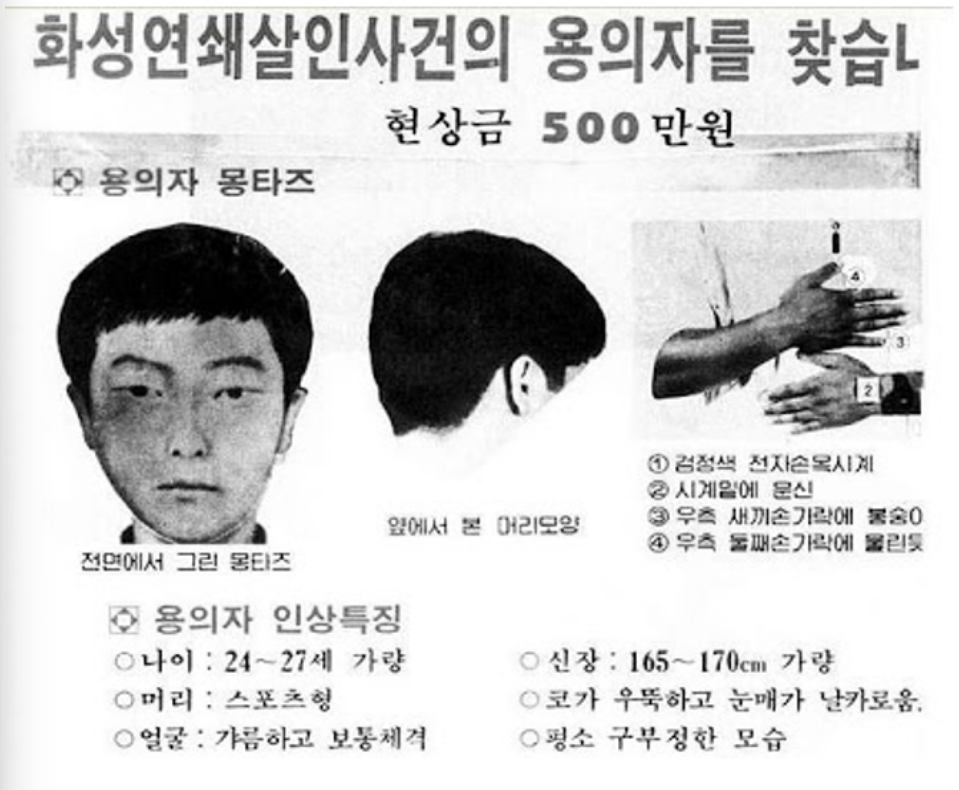
- 나쁜 특징: 데이터를 구별할 수 없는 특징
  - 눈이 2개
  - 귀가 2개
  - 검은색 머리카락
- 좋은 특징: 데이터를 잘 설명할 수 있는 특징
  - 뺨에 큰 붉은 반점
  - 쳐진 눈
  - 긴 갈색 생머리
- 특징의 종류
  - 연속 값(실수): 나이, 키, 몸무게, 소득
  - 카테고리 값(개수에 어느정도 제한이 있음): 성별, 직업, 거주지, 출신 학교

### 특징 추출 방법
- 전통적인 추출방법
  - 사람이 직접 가설을 세우고 특징을 추출
  - 장점: 모델의 동작 및 결과 해석이 쉬움
  - 단점: 가설 설정이 잘못되거나 생각하지 못한 특징이 있으면 성능이 떨어짐
- 딥러닝
  - 신경망 모델이 특징을 스스로 파악하고 추출함
  - 장점: 구현이 용이하고, 사람이 발견하지 못하는 특징을 활용할 수 있음
  - 단점: 모델을 해석할 수 없기 떄문에 성능이 떨어질 경우 원인을 분석하기 어려움

## 원 핫 인코딩

### 연속 vs 카테고리 값
- 연속 값 $\to$ 실수로 표현
  - 키, 몸무게 등
- 카테고리 값 $\to$ 이산(descrete)값. 단어나 클래스로 표현
- 차이점: 비슷한 수의 의미
  - 연속 값: 비슷함을 나타냄
  - 카테고리 값: 일치하지 않음을 나타냄
- 카테고리 값의 사례

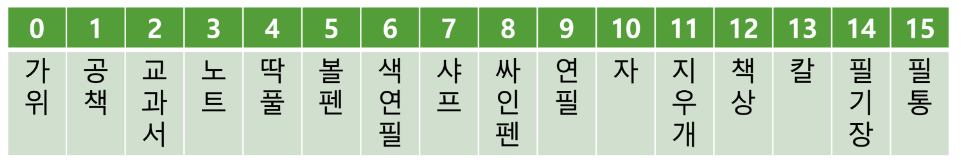
- 연필- 볼펜, 연필 - 자 사이의 관계(거리)
  - 상식: distance(연필, 볼펜) < distance(연필, 자)
  - 만약 distance를 위 그림의 인덱스로 표현하면, 부등호의 방향은 상식과 반대로 됨<br>
    |연필 - 볼펜| - 4 > 1 = |연필 - 자|
  - 따라서, 카테고리 값을 특징 벡터로 표현할 떄 인덱스를 사용할 수 없음

### 원 핫 인코딩(one-hot encoding)
- 한 개의 1과 n-1개의 0으로 구성된 n차원 벡터
- 연속값과 달리 카테고리 값은 특징 벡터로 표시할 때, 벡터간 거리는 의미가 없음
  - 연속값은 벡터간 거리가 가까울수록 유사한 데이터임(코사인 유사도, 유클리디안 거리, 멘해턴 거리 등)
  - 원 핫 벡터의 코사인 유사도는 0 $\to$ 직교(orthogonal)함
- 원 핫 인코딩은 카테고리 값 데이터를 벡터로 표현하기 위한 방법
- 대부분의 차원이 0이므로 매우 심한 화소 벡터(sparse vector)임 $\longleftrightarrow$ 고밀도 벡터(dense vector)

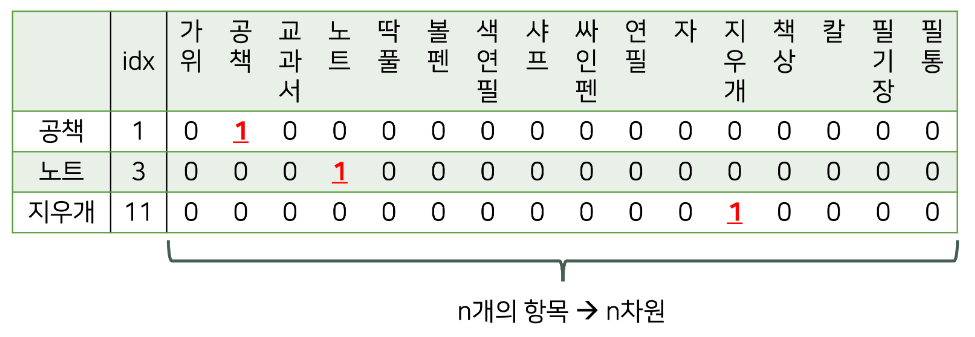

### 단어 임베딩
- 자연어 처리에 사용되는 단어 데이터를 표현하기 위한 벡터
- 단어 데이터를 원 핫 인코딩 벡터로 표현하면 단어 간의 유사도를 표현할 수 없음
  - '빨강'은 '파랑'보다 '분홍'과 더 유사하지만, 원 핫 인코딩에서는 알 수 없음
- Word2Vec 같은 방법을 사용하여 단어 임베딩을 표현함
  - 단어의 의미를 다차원 공간에 벡터화 $\to$ 분산 표현
  - one-hot-encoding이라는 고차원 벡터에 차원별로 분리해서 표현한 것을 저차원의 고밀도(dense) 벡터로 분산해서 표현

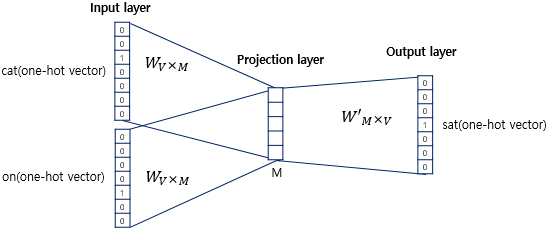

- ex) 단어가 10만 개 존재 -> 원 핫 인코딩 => 10만 개의 벡터 생성<br>
  원 핫 인코딩을 적절하게 나눠 고밀도 벡터로 표현할 수 있게 함

## 차원 축소
- 희소 벡터는 공간의 낭비가 심하기 때문에 밀도가 높은 벡터로 변환하는 방법이 필요함
  - 사례: MNIST의 숫자 이미지 데이터의 대부분은 0값을 가짐
 
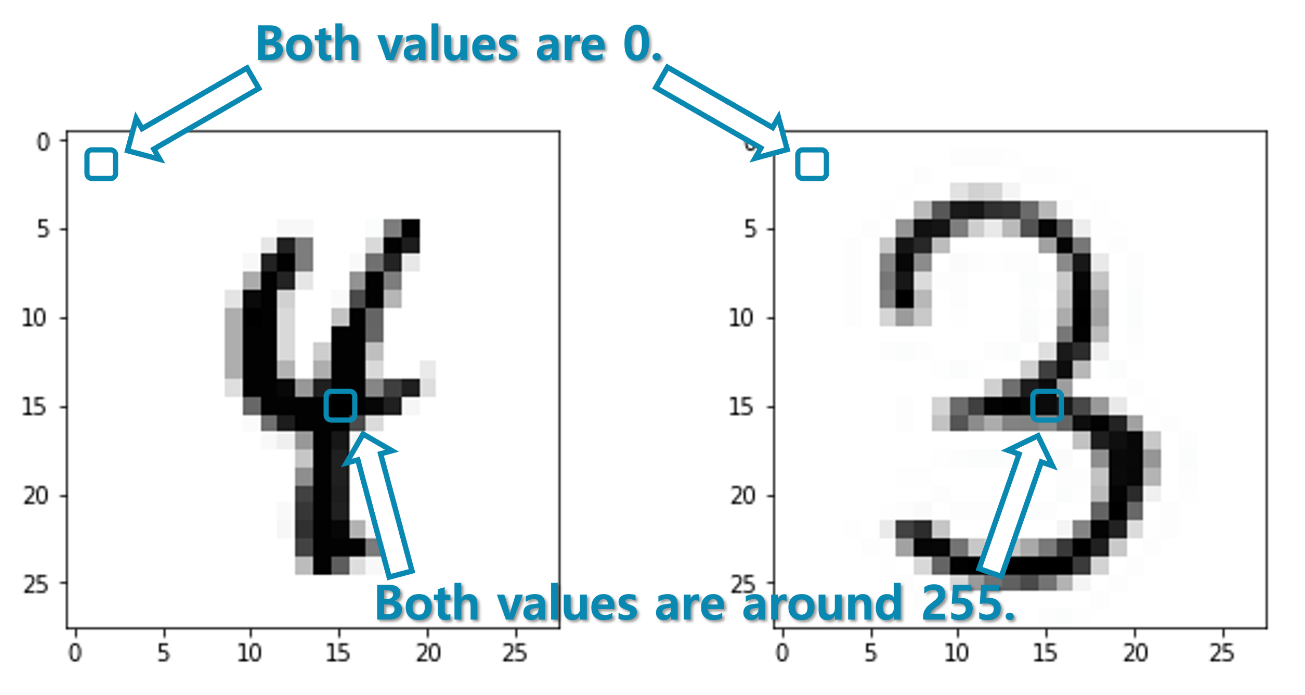

### 주성분 분석(PCA)
- 대표적인 선형 차원 축소 방법
- 데이터를 표현하는 새로운 축을 찾아서 다음 조건이 만족하는 축으로 데이터를 변환함
  - 모든 데이터를 새로운 축으로 투사하고, 투사된 데이터들 간의 거리의 합이 최대가 되도록 함
  - 데이터와 새로운 축 간의 직선거리의 총합이 최소가 되도록 함

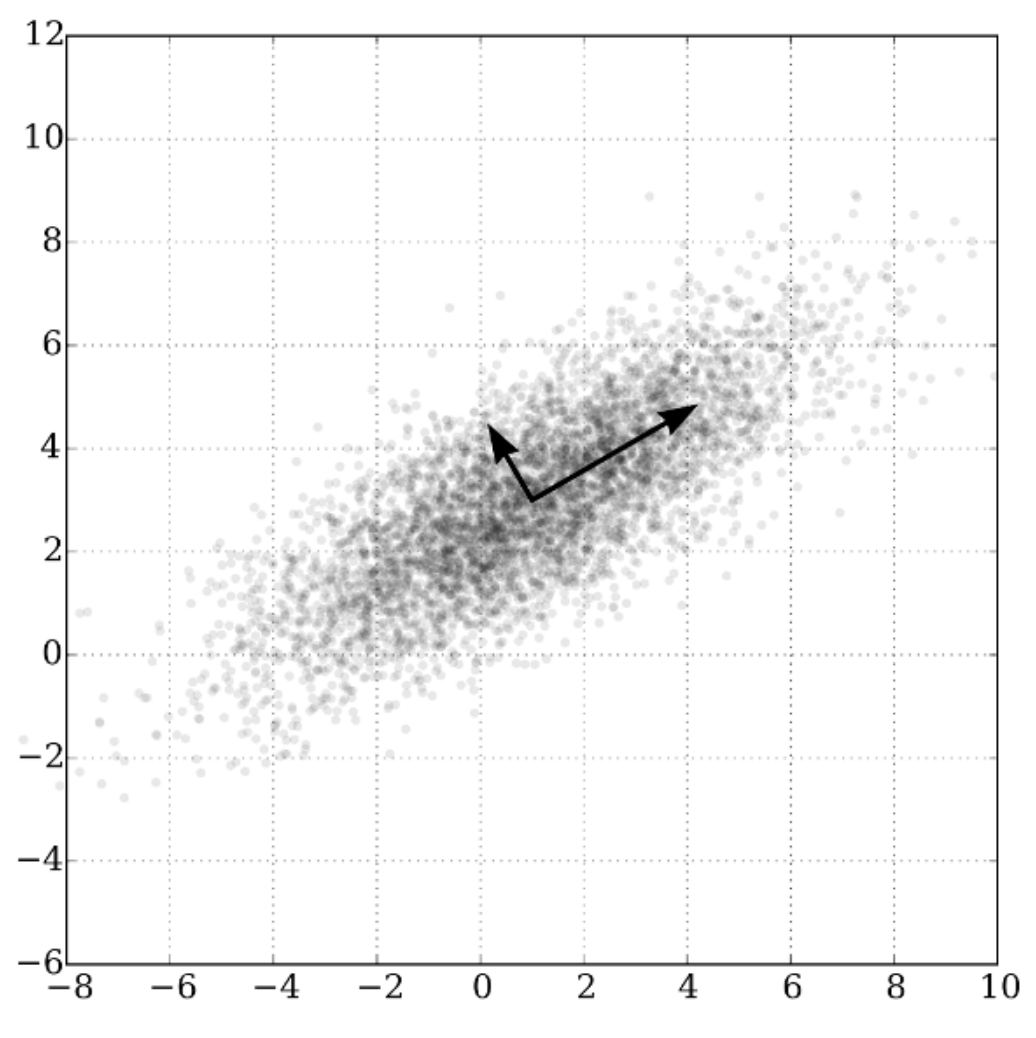

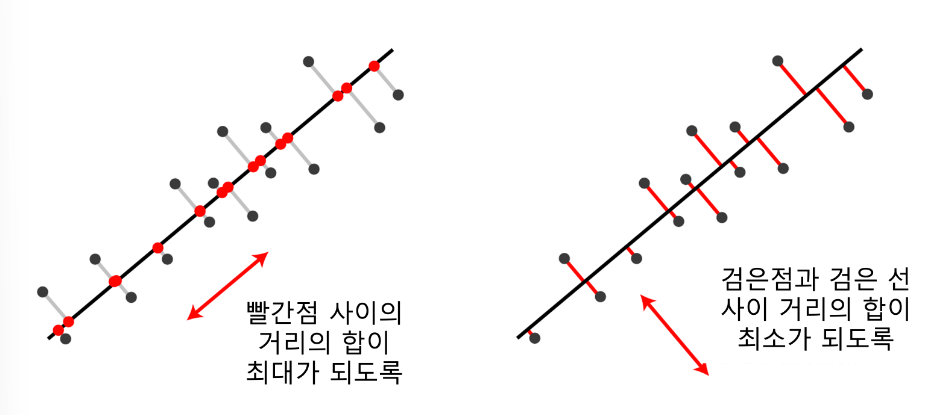
- PCA는 선형 차원 축소이므로 비선형적인 경계를 가진 데이터는 주성분을 찾기 어려움 $\to$ 비선형 차원 축소 필요
- 특징 1개에 차원이 1개 -> PCA를 통해 그 차원의 개수를 줄일 수 있음

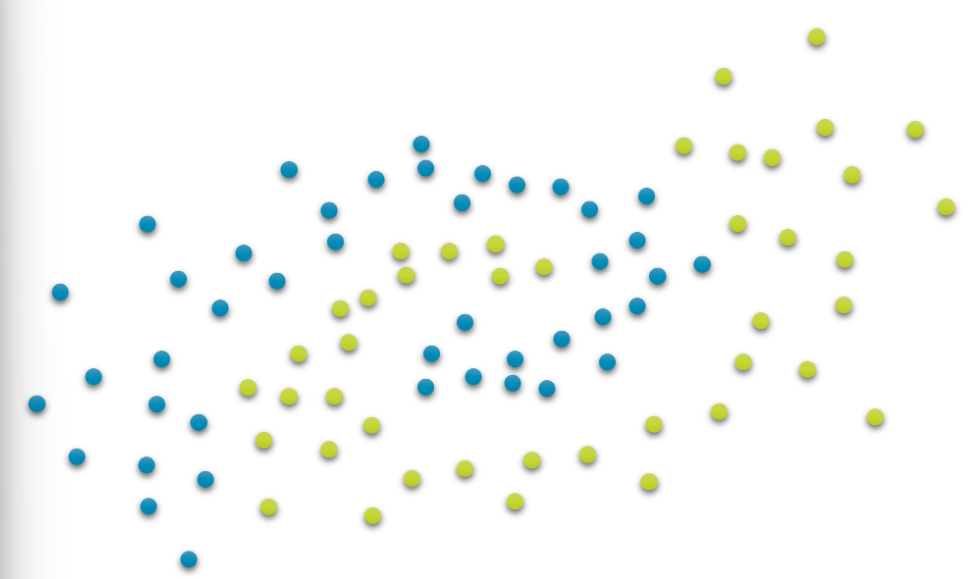

### 오토 인코더
- 비선형 차원 축소 방법
- 인코더와 디코더로 구성

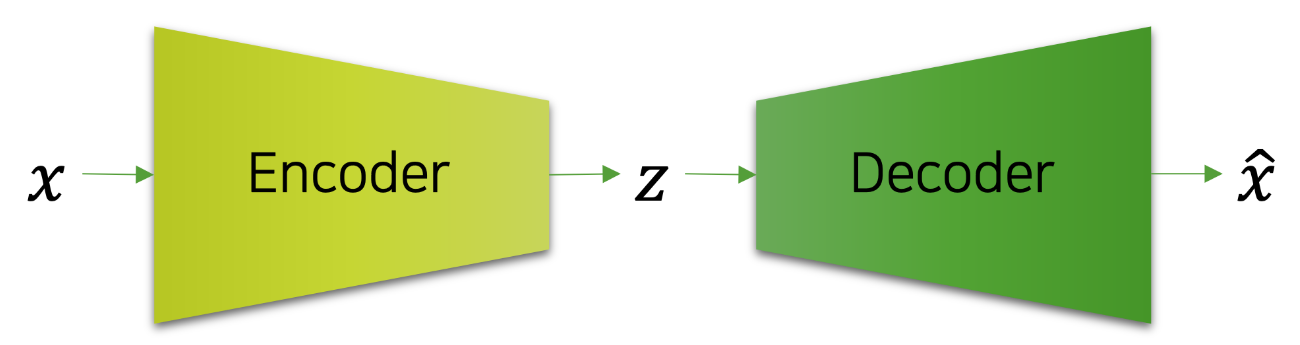
- 인코더는 데이터 압축과 유사하게 입력 데이터를 차원을 축소하여 중간 결과물($z$)을 생성함
  - 입력보다 적은 수의 뉴런으로 은닉층을 구성하여 학습함
- 인코더는 입력 샘플의 정보를 최대한 보존하도록 손실 압축을 수행함
- 디코더는 중간 결과물($z$)을 입력으로 받아서 입력과 똑같은 형태의 출력을 생성함
  - 인코더와 반대로 출력계층쪽으로 갈수록, 뉴런의 개수를 늘여서 출력층은 입력층과 같은 수의 뉴런을 갖도록 함
- 디코더는 압축된 중간 결과물로부터 입력과 최대한 같아지도록 압축을 해제함
- 오토인코더는 입력 샘플 $x$와 출력 벡터$\hat x$의 MSE 손실을 최소화하도록 학습함

- 은닉층에서 뉴런의 개수를 줄여서 요약함 -> 데이터 압축
- 인코더: 손실 압축 수행(손실은 무조건 존재할 수 밖에 없음)
- 디코더: 압축된 데이터를 최대한 해제 수행

### 은닉 표현
- 중간 결과물 벡터 $z$: 입력 샘플 $x$에 대한 은닉(잠재) 표현
- $x$가 존재하는 공간: 은닉 공간
- MNIST 데이터셋을 은닉 공간에 표현한 것

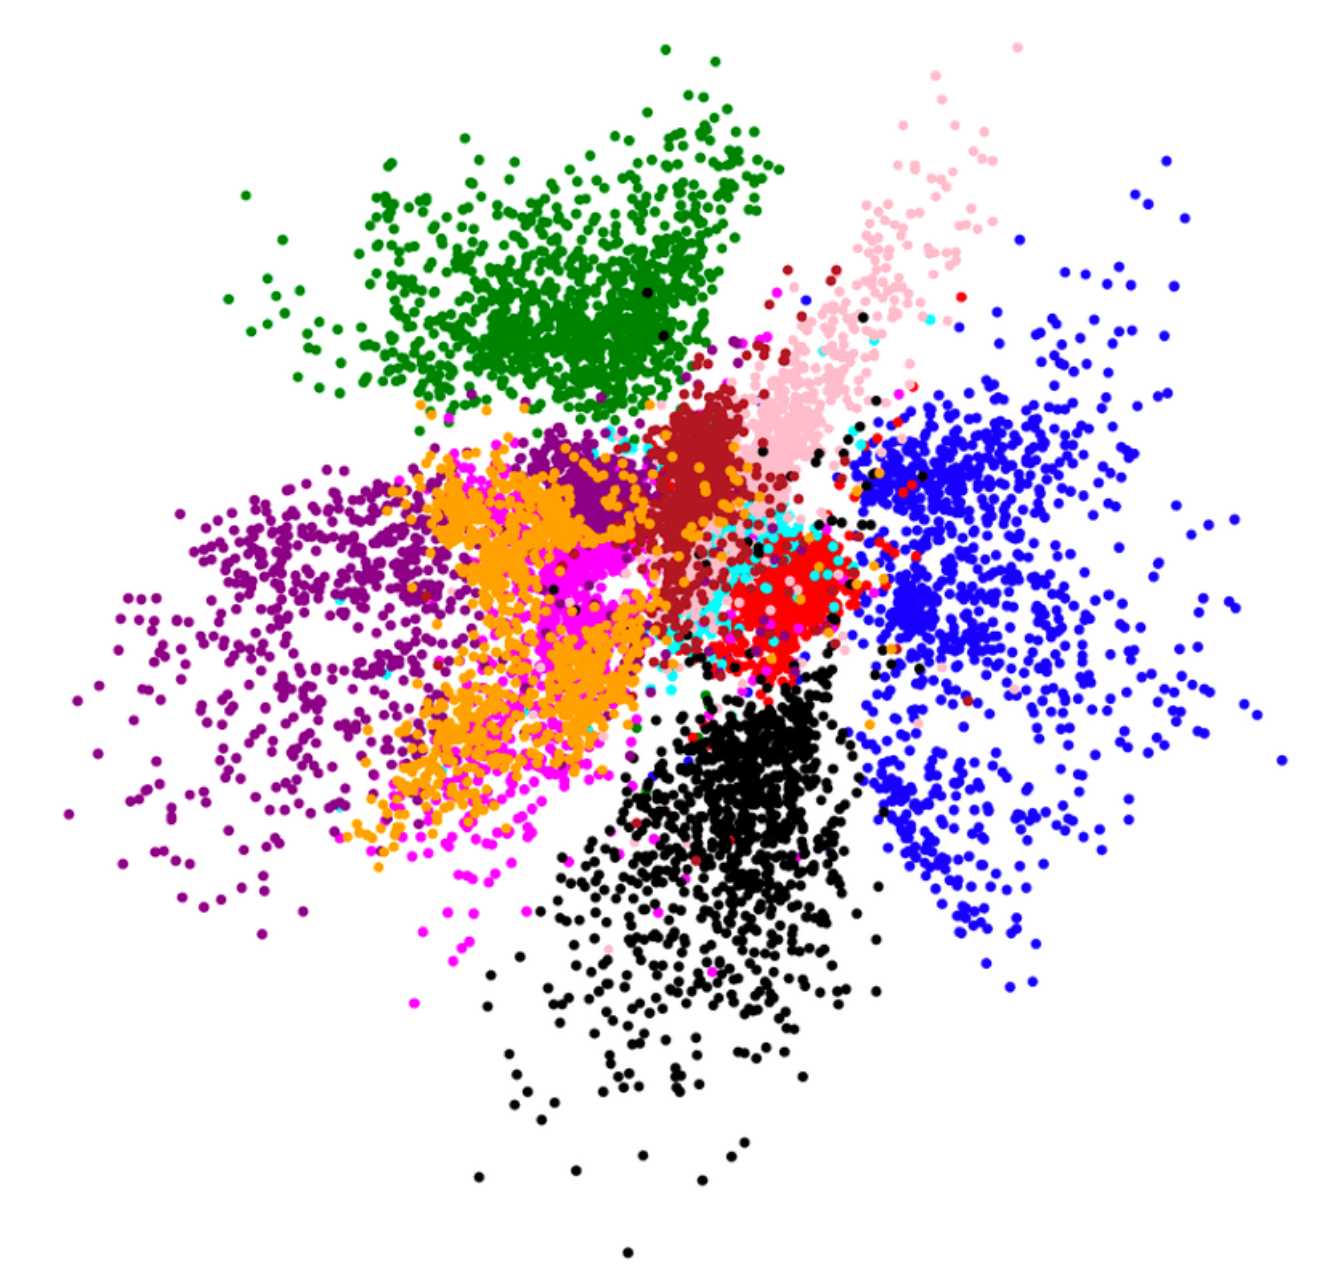
- 6만개의 데이터를 압축시키고 2차원에 뿌림 -> 정답의 종류를 색깔별로 나눔
  - 이 형태가 무엇을 의미하는지 데이터는 무엇인지 알 수 없음

### 왜 은닉인가?
- 은닉 벡터는 원하는 출력을 뱉어내는 데 필요한 정보를 해당 모델만 알고 있는 방법으로 감춰놓고 있다.
  - MNIST 샘플 벡터의 첫 번쨰 차원 $\to$ 첫 번째 픽셀
  - 은닉 벡터의 차원은? $\to$ 알 수 없음
  - 그러나 비슷한 특징을 가진 샘플은 비슷한 값을 가지는 것을 알 수 있음
  - 은닉 표현의 의미는 거의 해석 불가능
    - 최근에는 해석하려고 노력 중임 $\to$ 설명가능한 인공지능(XAI: eXplain AI)